In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings

# 忽略警告並設定中文
warnings.filterwarnings('ignore')
def set_ch_font():
    system = platform.system()
    if system == "Windows": plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    elif system == "Darwin": plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
set_ch_font()
sns.set_theme(style="whitegrid", font=plt.rcParams['font.sans-serif'])

# 讀取 01 產出的全表
df = pd.read_csv('../data/processed/yrbs_full_inspected.csv')
print(f"資料讀取成功，共 {len(df)} 筆，包含 {len(df.columns)} 個欄位。")

資料讀取成功，共 14041 筆，包含 103 個欄位。


Text(0.5, 1.0, '重編碼後：酒精使用二元分佈')

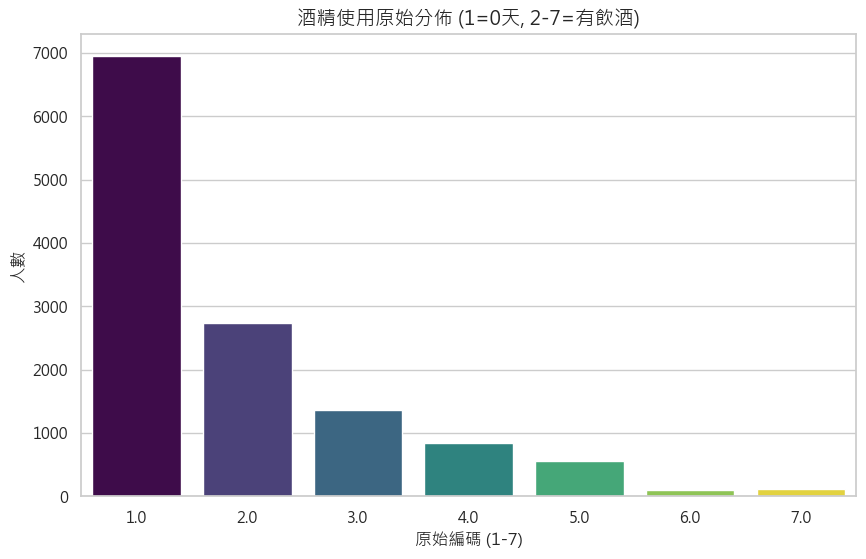

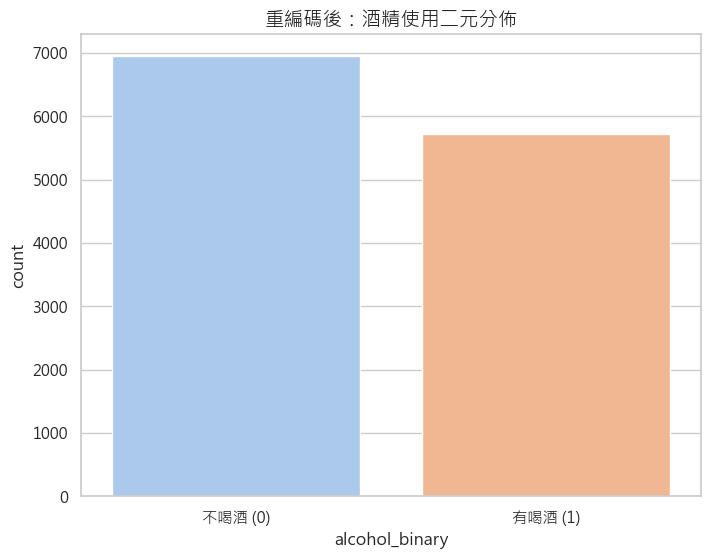

In [2]:
# 1. 排除酒精缺失值並建立副本
df_alc = df.dropna(subset=['CurrentAlcoholUse']).copy()

# 2. 原始分佈圖
fig_alc_raw = plt.figure(figsize=(10, 6))
sns.countplot(x='CurrentAlcoholUse', data=df_alc, palette='viridis', hue='CurrentAlcoholUse', legend=False)
plt.title('酒精使用原始分佈 (1=0天, 2-7=有飲酒)', fontsize=14)
plt.xlabel('原始編碼 (1-7)', fontsize=12)
plt.ylabel('人數', fontsize=12)

# 3. 執行二元重編碼 (Recoding)
# 定義：1 (0天) -> 0 (不喝酒) ; 2~7 -> 1 (有喝酒)
df_alc['alcohol_binary'] = df_alc['CurrentAlcoholUse'].apply(lambda x: 1 if x >= 2 else 0)

# 4. 二元化分佈圖
fig_alc_bin = plt.figure(figsize=(8, 6))
sns.countplot(x='alcohol_binary', data=df_alc, palette='pastel', hue='alcohol_binary', legend=False)
plt.xticks([0, 1], ['不喝酒 (0)', '有喝酒 (1)'])
plt.title('重編碼後：酒精使用二元分佈', fontsize=14)

In [5]:
# --- 1. 酒精變數：原始編碼頻率表 ---
print("【表 2-1：CurrentAlcoholUse 原始頻率表】")
# 包括缺失值與無效值 (如果有)
original_freq = df['CurrentAlcoholUse'].value_counts(dropna=False).sort_index()
print(original_freq)

# --- 2. 缺失與無效值計算 ---
missing_alc = df['CurrentAlcoholUse'].isnull().sum()
invalid_alc = len(df[~df['CurrentAlcoholUse'].isin(range(1, 8))]) # 假設有效值是 1-7
print(f"\n缺失值數量: {missing_alc}")
print(f"無效值數量: {invalid_alc}")

# --- 3. 重編碼後的頻率與比例 (Success/Failure) ---
# 0 = 不喝酒 (Failure), 1 = 有喝酒 (Success)
alc_stats = df_alc['alcohol_binary'].value_counts()
alc_proportions = df_alc['alcohol_binary'].value_counts(normalize=True)

summary_table_alc = pd.DataFrame({
    '人數 (Counts)': alc_stats,
    '比例 (Proportions)': alc_proportions
})
print("\n【表 2-2：重編碼後之酒精使用統計 (0=不喝酒, 1=有喝酒)】")
print(summary_table_alc)

【表 2-1：CurrentAlcoholUse 原始頻率表】
CurrentAlcoholUse
1.0    6946
2.0    2735
3.0    1369
4.0     839
5.0     555
6.0     105
7.0     120
NaN    1372
Name: count, dtype: int64

缺失值數量: 1372
無效值數量: 1372

【表 2-2：重編碼後之酒精使用統計 (0=不喝酒, 1=有喝酒)】
                人數 (Counts)  比例 (Proportions)
alcohol_binary                               
0                      6946          0.548267
1                      5723          0.451733


Text(0.5, 1.0, '體重分佈箱線圖 (Outlier Check)')

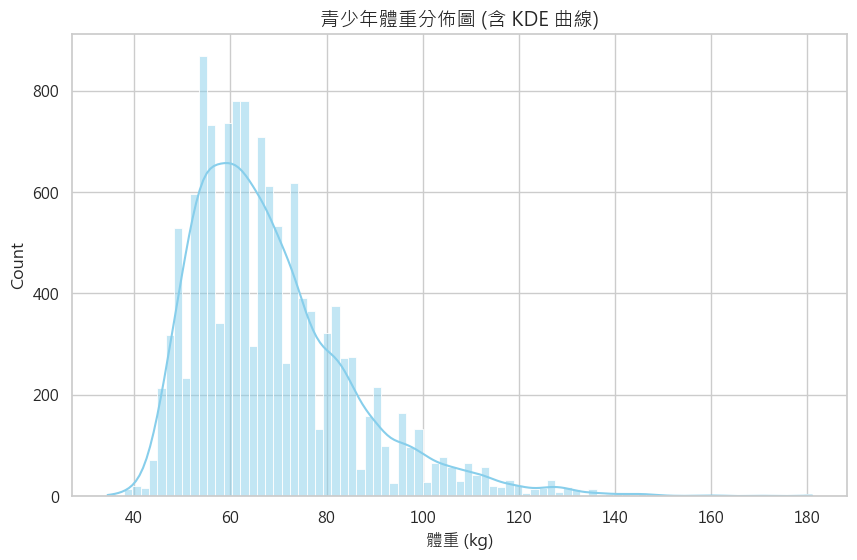

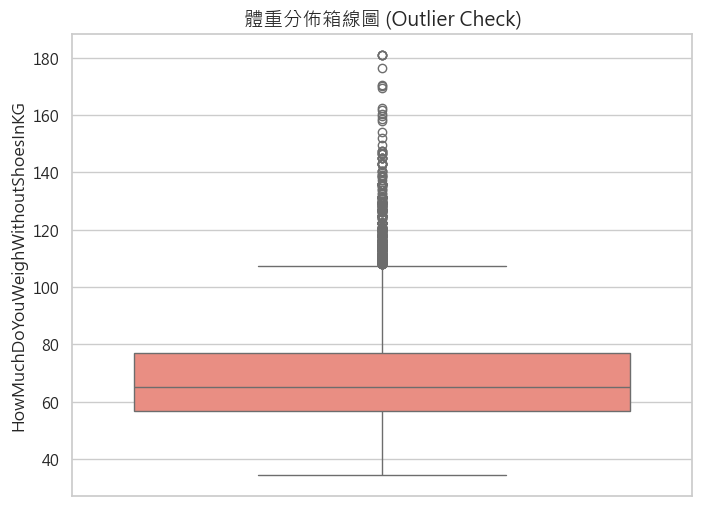

In [3]:
# 1. 排除體重缺失值
df_weight = df.dropna(subset=['HowMuchDoYouWeighWithoutShoesInKG']).copy()

# 2. 體重直方圖 (密度估計)
fig_weight_hist = plt.figure(figsize=(10, 6))
sns.histplot(df_weight['HowMuchDoYouWeighWithoutShoesInKG'], kde=True, color='skyblue')
plt.title('青少年體重分佈圖 (含 KDE 曲線)', fontsize=14)
plt.xlabel('體重 (kg)', fontsize=12)

# 3. 體重箱線圖 (找離群值)
fig_weight_box = plt.figure(figsize=(8, 6))
sns.boxplot(y=df_weight['HowMuchDoYouWeighWithoutShoesInKG'], color='salmon')
plt.title('體重分佈箱線圖 (Outlier Check)', fontsize=14)

In [6]:
# --- 1. 體重描述性統計 ---
weight_series = df_weight['HowMuchDoYouWeighWithoutShoesInKG']

# 計算各項指標
desc_stats = {
    '樣本數 (n)': len(weight_series),
    '平均值 (Mean)': weight_series.mean(),
    '中位數 (Median)': weight_series.median(),
    '標準差 (SD)': weight_series.std(),
    '最小值 (Min)': weight_series.min(),
    '第一四分位數 (Q1)': weight_series.quantile(0.25),
    '第三四分位數 (Q3)': weight_series.quantile(0.75),
    '最大值 (Max)': weight_series.max(),
    '缺失值數量': df['HowMuchDoYouWeighWithoutShoesInKG'].isnull().sum()
}
print("【表 2-3：體重數據統計摘要】")
for k, v in desc_stats.items(): print(f"{k}: {v:.2f}")

# --- 2. 離群值檢查 (Outlier Check) ---
Q1 = weight_series.quantile(0.25)
Q3 = weight_series.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = weight_series[(weight_series < lower_bound) | (weight_series > upper_bound)]

print(f"\n離群值判定界線: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"偵測到離群值數量: {len(outliers)}")

【表 2-3：體重數據統計摘要】
樣本數 (n): 13062.00
平均值 (Mean): 68.55
中位數 (Median): 65.32
標準差 (SD): 16.99
最小值 (Min): 34.47
第一四分位數 (Q1): 56.70
第三四分位數 (Q3): 77.11
最大值 (Max): 180.99
缺失值數量: 979.00

離群值判定界線: [26.09, 107.72]
偵測到離群值數量: 447


In [8]:
# 建立表格存放資料夾
os.makedirs('../outputs/tables/', exist_ok=True)

# 存出統計摘要
summary_table_alc.to_csv('../outputs/tables/02_alcohol_summary.csv')
pd.DataFrame(desc_stats, index=['Value']).T.to_csv('../outputs/tables/02_weight_summary.csv')